In [1]:
import numpy as np 
import pandas as pd 
import math
import random
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn import metrics
from sklearn import svm
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import roc_auc_score
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.dummy import DummyClassifier
from imblearn.metrics import geometric_mean_score
from imblearn.over_sampling import SMOTE
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter

In [2]:
data=pd.read_csv("UNR-IDD.csv")

In [3]:
data

,Switch_ID,Port_Number,Received_Packets,Received_Bytes,Sent_Bytes,Sent_Packets,Port_alive_Duration,Packets_Rx_Dropped,Packets_Tx_Dropped,Packets_Rx_Errors,...,Unknown_Load_Latest,Latest_bytes_counter,is_valid,Table_ID,Active_Flow_Entries,Packets_Looked_Up,Packets_Matched,Max_Size,Label,Binary_Label
0,of:000000000000000c,Port#:1,132,9181,6311853,238,46,0,0,0,...,0,0,True,0,9,767,688,-1,TCP-SYN,Attack
1,of:000000000000000c,Port#:2,187,6304498,15713,171,46,0,0,0,...,0,0,True,0,9,767,688,-1,TCP-SYN,Attack
2,of:000000000000000c,Port#:3,235,6311567,8030,58,46,0,0,0,...,0,0,True,0,9,767,688,-1,TCP-SYN,Attack
3,of:000000000000000c,Port#:4,59,7878,16439,182,46,0,0,0,...,0,0,True,0,9,767,688,-1,TCP-SYN,Attack
4,of:000000000000000a,Port#:1,188,6304547,16497,183,46,0,0,0,...,0,0,True,0,7,489,403,-1,TCP-SYN,Attack
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37406,of:0000000000000006,Port#:2,228,30195,7857046,145141,276,0,0,0,...,0,0,True,0,6,147563,147454,-1,PortScan,Attack
37407,of:0000000000000006,Port#:3,1064,18962056,37732,338,276,0,0,0,...,0,0,True,0,6,147563,147454,-1,PortScan,Attack
37408,of:0000000000000009,Port#:1,1042,25252012,7856976,145140,276,0,0,0,...,0,0,True,0,8,295511,295404,-1,PortScan,Attack
37409,of:0000000000000009,Port#:2,149012,14360115,29509,211,276,0,0,0,...,0,0,True,0,8,295511,295404,-1,PortScan,Attack


In [4]:
data.drop(['Binary_Label'], axis=1, inplace=True)

In [5]:
data.Port_Number = pd.factorize(data.Port_Number)[0] + 1

data.is_valid = pd.factorize(data.is_valid)[0] + 1

data.Switch_ID = pd.factorize(data.Switch_ID)[0] + 1


In [6]:
data.describe(include="all")

,Switch_ID,Port_Number,Received_Packets,Received_Bytes,Sent_Bytes,Sent_Packets,Port_alive_Duration,Packets_Rx_Dropped,Packets_Tx_Dropped,Packets_Rx_Errors,...,Unknown_Load_Rate,Unknown_Load_Latest,Latest_bytes_counter,is_valid,Table_ID,Active_Flow_Entries,Packets_Looked_Up,Packets_Matched,Max_Size,Label
count,37411.000000,37411.000000,37411.000000,3.741100e+04,3.741100e+04,37411.000000,37411.000000,37411.0,37411.0,37411.0,...,3.741100e+04,3.741100e+04,3.741100e+04,37411.0,37411.0,37411.000000,3.741100e+04,3.741100e+04,37411.0,37411
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PortScan
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9500
mean,5.272193,2.172676,21618.897169,2.647491e+07,2.451212e+07,33626.824009,911.096415,0.0,0.0,0.0,...,1.921455e+04,5.145597e+05,1.921455e+04,1.0,0.0,88.690572,1.008636e+05,1.007444e+05,-1.0,NaN
std,3.335869,1.015155,65283.170126,3.703044e+07,3.439876e+07,88792.970378,982.113446,0.0,0.0,0.0,...,1.107441e+05,1.863403e+06,1.107441e+05,0.0,0.0,790.715343,2.350297e+05,2.350284e+05,0.0,NaN
min,1.000000,1.000000,9.000000,7.860000e+02,5.705000e+03,41.000000,26.000000,0.0,0.0,0.0,...,-1.284277e+06,0.000000e+00,-1.284277e+06,1.0,0.0,4.000000,8.700000e+01,3.700000e+01,-1.0,NaN
25%,2.000000,1.000000,329.000000,9.104050e+04,5.775950e+04,347.000000,136.000000,0.0,0.0,0.0,...,0.000000e+00,0.000000e+00,0.000000e+00,1.0,0.0,5.000000,2.367000e+03,2.272000e+03,-1.0,NaN
50%,5.000000,2.000000,1170.000000,1.263052e+07,1.262658e+07,1240.000000,259.000000,0.0,0.0,0.0,...,0.000000e+00,0.000000e+00,0.000000e+00,1.0,0.0,6.000000,7.472000e+03,7.349000e+03,-1.0,NaN
75%,8.000000,3.000000,3417.000000,3.783230e+07,3.176443e+07,3968.000000,1747.000000,0.0,0.0,0.0,...,0.000000e+00,0.000000e+00,0.000000e+00,1.0,0.0,8.000000,2.343700e+04,2.322000e+04,-1.0,NaN


In [7]:
gb=data.groupby("Label")
gb.size()

Label
Blackhole    8420
Diversion    5615
Normal       3773
Overflow     1022
PortScan     9500
TCP-SYN      9081
dtype: int64

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37411 entries, 0 to 37410
Data columns (total 33 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Switch_ID                  37411 non-null  int64 
 1   Port_Number                37411 non-null  int64 
 2   Received_Packets           37411 non-null  int64 
 3   Received_Bytes             37411 non-null  int64 
 4   Sent_Bytes                 37411 non-null  int64 
 5   Sent_Packets               37411 non-null  int64 
 6   Port_alive_Duration        37411 non-null  int64 
 7   Packets_Rx_Dropped         37411 non-null  int64 
 8   Packets_Tx_Dropped         37411 non-null  int64 
 9   Packets_Rx_Errors          37411 non-null  int64 
 10  Packets_Tx_Errors          37411 non-null  int64 
 11  Delta_Received_Packets     37411 non-null  int64 
 12  Delta_Received_Bytes       37411 non-null  int64 
 13  Delta_Sent_Bytes           37411 non-null  int64 
 14  Delta_

In [9]:
data.Label = pd.factorize(data.Label)[0] + 1

In [10]:
y = data['Label']

In [11]:
X_train, X_test, Y_train, Y_test = train_test_split(data, y, train_size=.7)

In [12]:
from sklearn.ensemble import RandomForestClassifier

feature_names = [f"feature {i}" for i in range(data.shape[1])]
forest = RandomForestClassifier(random_state=0)
forest.fit(X_train, Y_train)
importances = forest.feature_importances_
std = np.std([tree.feature_importances_ for tree in forest.estimators_], axis=0)

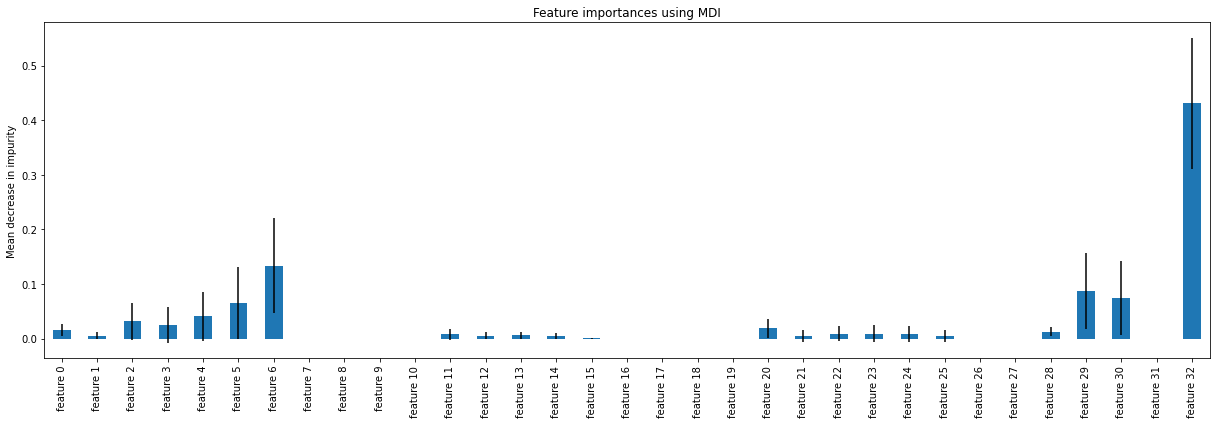

In [13]:
forest_importances = pd.Series(importances, index=feature_names)

#fig, ax = plt.subplots()
fig, ax = plt.subplots(figsize=(17, 6))
forest_importances.plot.bar(yerr=std, ax=ax)
ax.set_title("Feature importances using MDI")
ax.set_ylabel("Mean decrease in impurity")
fig.tight_layout()
#plt.show()

In [14]:
new_data = data.drop(['Packets_Rx_Dropped', 'Packets_Tx_Dropped', 'Packets_Rx_Errors', 'Packets_Tx_Errors', 'Delta_Port_alive_Duration', 'Delta_Packets_Rx_Dropped', ' Delta_Packets_Tx_Dropped', 'Delta_Packets _Rx_Errors', 'Delta_Packets_Tx_Errors', 'is_valid', 'Table_ID', 'Max_Size'], axis=1, inplace=True)

In [15]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37411 entries, 0 to 37410
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Switch_ID               37411 non-null  int64
 1   Port_Number             37411 non-null  int64
 2   Received_Packets        37411 non-null  int64
 3   Received_Bytes          37411 non-null  int64
 4   Sent_Bytes              37411 non-null  int64
 5   Sent_Packets            37411 non-null  int64
 6   Port_alive_Duration     37411 non-null  int64
 7   Delta_Received_Packets  37411 non-null  int64
 8   Delta_Received_Bytes    37411 non-null  int64
 9   Delta_Sent_Bytes        37411 non-null  int64
 10  Delta_Sent_Packets      37411 non-null  int64
 11  Connection_Point        37411 non-null  int64
 12  Total_Load_Rate         37411 non-null  int64
 13  Total_Load_Latest       37411 non-null  int64
 14  Unknown_Load_Rate       37411 non-null  int64
 15  Unknown_Load_Latest

In [16]:
y = data['Label']

In [17]:
X_train, X_test, Y_train, Y_test = train_test_split(data, y, train_size=.7)

In [18]:
feature_names = [f"feature {i}" for i in range(data.shape[1])]
forest = RandomForestClassifier(random_state=0)
forest.fit(X_train, Y_train)
importances = forest.feature_importances_
std = np.std([tree.feature_importances_ for tree in forest.estimators_], axis=0)

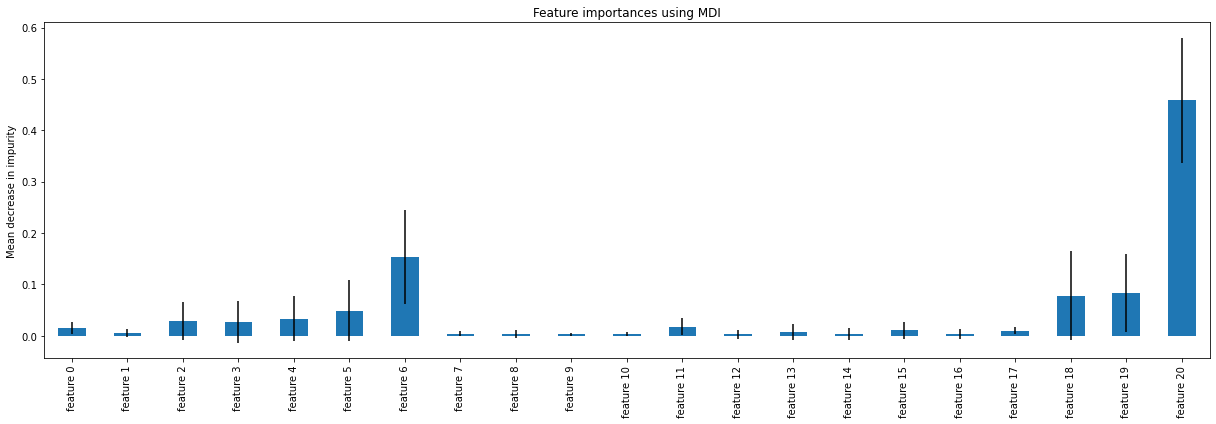

In [19]:
forest_importances = pd.Series(importances, index=feature_names)

#fig, ax = plt.subplots()
fig, ax = plt.subplots(figsize=(17, 6))
forest_importances.plot.bar(yerr=std, ax=ax)
ax.set_title("Feature importances using MDI")
ax.set_ylabel("Mean decrease in impurity")
fig.tight_layout()
#plt.show()

In [20]:
gb=data.groupby("Label")

In [21]:
gb.size()

Label
1    9081
2    8420
3    5615
4    1022
5    3773
6    9500
dtype: int64

In [22]:
gb.get_group(1)

,Switch_ID,Port_Number,Received_Packets,Received_Bytes,Sent_Bytes,Sent_Packets,Port_alive_Duration,Delta_Received_Packets,Delta_Received_Bytes,Delta_Sent_Bytes,...,Connection_Point,Total_Load_Rate,Total_Load_Latest,Unknown_Load_Rate,Unknown_Load_Latest,Latest_bytes_counter,Active_Flow_Entries,Packets_Looked_Up,Packets_Matched,Label
0,1,1,132,9181,6311853,238,46,0,0,280,...,1,0,0,0,0,0,9,767,688,1
1,1,2,187,6304498,15713,171,46,146,5908166,5969,...,2,0,0,0,0,0,9,767,688,1
2,1,3,235,6311567,8030,58,46,2,278,280,...,3,0,0,0,0,0,9,767,688,1
3,1,4,59,7878,16439,182,46,2,278,280,...,4,0,0,0,0,0,9,767,688,1
4,2,1,188,6304547,16497,183,46,0,0,280,...,1,0,0,0,0,0,7,489,403,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9076,11,2,162,21248,29441,282,181,4,556,2219,...,2,205,8077,205,8077,205,5,2010,1906,1
9077,11,3,511,12628160,21248,162,181,4,556,556,...,3,0,0,0,0,0,5,2010,1906,1
9078,12,1,1064,12666066,29441,282,181,4,556,2219,...,1,205,8077,205,8077,205,6,4548,4449,1
9079,12,2,2879,167858,20618,147,181,102,5836,556,...,3,0,0,0,0,0,6,4548,4449,1


In [23]:
result = gb.get_group(1).append([gb.get_group(2), gb.get_group(3), gb.get_group(5), gb.get_group(6) ], ignore_index='True')


In [24]:
result

,Switch_ID,Port_Number,Received_Packets,Received_Bytes,Sent_Bytes,Sent_Packets,Port_alive_Duration,Delta_Received_Packets,Delta_Received_Bytes,Delta_Sent_Bytes,...,Connection_Point,Total_Load_Rate,Total_Load_Latest,Unknown_Load_Rate,Unknown_Load_Latest,Latest_bytes_counter,Active_Flow_Entries,Packets_Looked_Up,Packets_Matched,Label
0,1,1,132,9181,6311853,238,46,0,0,280,...,1,0,0,0,0,0,9,767,688,1
1,1,2,187,6304498,15713,171,46,146,5908166,5969,...,2,0,0,0,0,0,9,767,688,1
2,1,3,235,6311567,8030,58,46,2,278,280,...,3,0,0,0,0,0,9,767,688,1
3,1,4,59,7878,16439,182,46,2,278,280,...,4,0,0,0,0,0,9,767,688,1
4,2,1,188,6304547,16497,183,46,0,0,280,...,1,0,0,0,0,0,7,489,403,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36384,11,2,228,30195,7857046,145141,276,4,556,288376,...,2,0,0,0,0,0,6,147563,147454,6
36385,11,3,1064,18962056,37732,338,276,4,556,556,...,3,0,0,0,0,0,6,147563,147454,6
36386,12,1,1042,25252012,7856976,145140,276,4,556,288376,...,1,0,0,0,0,0,8,295511,295404,6
36387,12,2,149012,14360115,29509,211,276,5381,291755,556,...,3,0,0,0,0,0,8,295511,295404,6


In [25]:
#Spliting the dataset into groups according to the label attribute
new_gb = result.groupby("Label")

In [26]:
new_gb.size()

Label
1    9081
2    8420
3    5615
5    3773
6    9500
dtype: int64

In [27]:
target = result['Label']

In [28]:
result

,Switch_ID,Port_Number,Received_Packets,Received_Bytes,Sent_Bytes,Sent_Packets,Port_alive_Duration,Delta_Received_Packets,Delta_Received_Bytes,Delta_Sent_Bytes,...,Connection_Point,Total_Load_Rate,Total_Load_Latest,Unknown_Load_Rate,Unknown_Load_Latest,Latest_bytes_counter,Active_Flow_Entries,Packets_Looked_Up,Packets_Matched,Label
0,1,1,132,9181,6311853,238,46,0,0,280,...,1,0,0,0,0,0,9,767,688,1
1,1,2,187,6304498,15713,171,46,146,5908166,5969,...,2,0,0,0,0,0,9,767,688,1
2,1,3,235,6311567,8030,58,46,2,278,280,...,3,0,0,0,0,0,9,767,688,1
3,1,4,59,7878,16439,182,46,2,278,280,...,4,0,0,0,0,0,9,767,688,1
4,2,1,188,6304547,16497,183,46,0,0,280,...,1,0,0,0,0,0,7,489,403,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36384,11,2,228,30195,7857046,145141,276,4,556,288376,...,2,0,0,0,0,0,6,147563,147454,6
36385,11,3,1064,18962056,37732,338,276,4,556,556,...,3,0,0,0,0,0,6,147563,147454,6
36386,12,1,1042,25252012,7856976,145140,276,4,556,288376,...,1,0,0,0,0,0,8,295511,295404,6
36387,12,2,149012,14360115,29509,211,276,5381,291755,556,...,3,0,0,0,0,0,8,295511,295404,6


In [29]:
target

0        1
1        1
2        1
3        1
4        1
        ..
36384    6
36385    6
36386    6
36387    6
36388    6
Name: Label, Length: 36389, dtype: int64

Oversampling

In [30]:

ros = RandomOverSampler(random_state=42)

X_res, y_res = ros.fit_resample(result, target)


Undersampling

In [31]:
#rus = RandomUnderSampler(random_state=42)

#X_res, y_res = rus.fit_resample(result, target)

In [32]:
print('Resampled dataset shape %s' % Counter(y_res))

Resampled dataset shape Counter({1: 9500, 2: 9500, 3: 9500, 5: 9500, 6: 9500})


In [33]:
X_res

,Switch_ID,Port_Number,Received_Packets,Received_Bytes,Sent_Bytes,Sent_Packets,Port_alive_Duration,Delta_Received_Packets,Delta_Received_Bytes,Delta_Sent_Bytes,...,Connection_Point,Total_Load_Rate,Total_Load_Latest,Unknown_Load_Rate,Unknown_Load_Latest,Latest_bytes_counter,Active_Flow_Entries,Packets_Looked_Up,Packets_Matched,Label
0,1,1,132,9181,6311853,238,46,0,0,280,...,1,0,0,0,0,0,9,767,688,1
1,1,2,187,6304498,15713,171,46,146,5908166,5969,...,2,0,0,0,0,0,9,767,688,1
2,1,3,235,6311567,8030,58,46,2,278,280,...,3,0,0,0,0,0,9,767,688,1
3,1,4,59,7878,16439,182,46,2,278,280,...,4,0,0,0,0,0,9,767,688,1
4,2,1,188,6304547,16497,183,46,0,0,280,...,1,0,0,0,0,0,7,489,403,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47495,3,1,2245,56777549,48002251,240178,2000,0,0,560,...,1,630328,6303287,630328,6303287,630328,6,513793,513711,5
47496,4,2,6588,126282067,194140082,420124,2507,0,0,556,...,2,0,0,0,0,0,9,1004855,1004720,5
47497,5,2,284354,93924452,25499849,305060,1580,4,556,278,...,4,351,14173,351,14173,351,6,956341,956209,5
47498,1,1,2641,50513231,86630372,410963,1607,0,0,280,...,1,630328,6303285,630328,6303285,630328,6,654113,653987,5


In [34]:
gb_new_SMOTE = X_res.groupby("Label")

In [35]:
gb_new_SMOTE.size()

Label
1    9500
2    9500
3    9500
5    9500
6    9500
dtype: int64

In [36]:
X_train, X_test, Y_train, Y_test = train_test_split(X_res, y_res, train_size=.7)

In [37]:
#Loading the Classifier model
model=svm.SVC(C = 1, probability=True)
clf = DecisionTreeClassifier(random_state=0, max_depth=5)
knn = KNeighborsClassifier(n_neighbors=5)

In [38]:
#Train the model using the training sets
model.fit(X_train, Y_train)
clf = clf.fit(X_train, Y_train)
knn = knn.fit(X_train, Y_train)

In [39]:
#prule_pred_proba=prule.predict_proba(X_test)
model_pred_proba=model.predict_proba(X_test)
clf_pred_proba=clf.predict_proba(X_test)
knn_pred_proba=knn.predict_proba(X_test)

In [40]:
model_X_train_pred=model.predict(X_train)
model_X_test_pred=model.predict(X_test)
clf_X_train_pred=clf.predict(X_train)
clf_X_test_pred=clf.predict(X_test)
knn_X_train_pred=knn.predict(X_train)
knn_X_test_pred=knn.predict(X_test)

In [41]:
print("Accuracy for SVM Test Data:                        ", metrics.accuracy_score(Y_test, model_X_test_pred))
print("Accuracy for Decision Tree Classifier Test Data:   ", metrics.accuracy_score(Y_test, clf_X_test_pred))
print("Accuracy for KNN Test Data:                        ", metrics.accuracy_score(Y_test, knn_X_test_pred))

Accuracy for SVM Test Data:                         0.5419649122807018
Accuracy for Decision Tree Classifier Test Data:    1.0
Accuracy for KNN Test Data:                         0.8425263157894737


In [42]:
model_gmean=geometric_mean_score(Y_test, model_X_test_pred, average='weighted')
clf_gmean=geometric_mean_score(Y_test, clf_X_test_pred, average='weighted')
knn_gmean=geometric_mean_score(Y_test, knn_X_test_pred, average='weighted')

In [43]:
print("G mean for SVM Test Data:                           ", model_gmean)
print("G mean for Decision Tree Classifier Test Data:      ", clf_gmean)
print("G mean for KNN Test Data:                           ", knn_gmean)

G mean for SVM Test Data:                            0.6927356524208834
G mean for Decision Tree Classifier Test Data:       1.0
G mean for KNN Test Data:                            0.8996289084587715


In [44]:
### Decision Tree

In [45]:
cm_model_test=confusion_matrix(Y_test, clf_X_test_pred)

In [46]:
cm_model_test

array([[2910,    0,    0,    0,    0],
       [   0, 2860,    0,    0,    0],
       [   0,    0, 2854,    0,    0],
       [   0,    0,    0, 2855,    0],
       [   0,    0,    0,    0, 2771]], dtype=int64)

In [48]:
disp_model = ConfusionMatrixDisplay(confusion_matrix=cm_model_test, display_labels=["Blackhole", "Diversion", "Normal", "PortScan", "TCP-SYN" ])

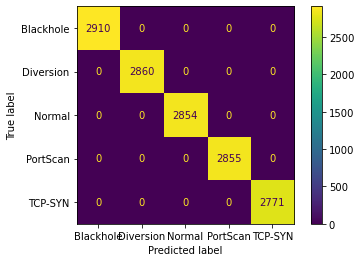

In [49]:
disp_model.plot() 

In [50]:
print(metrics.classification_report(Y_test, clf_X_test_pred, digits=3))

              precision    recall  f1-score   support

           1      1.000     1.000     1.000      2910
           2      1.000     1.000     1.000      2860
           3      1.000     1.000     1.000      2854
           5      1.000     1.000     1.000      2855
           6      1.000     1.000     1.000      2771

    accuracy                          1.000     14250
   macro avg      1.000     1.000     1.000     14250
weighted avg      1.000     1.000     1.000     14250



In [51]:
### KNN

In [52]:
knn_model_test=confusion_matrix(Y_test, knn_X_test_pred)

In [53]:
knn_model_test

array([[2390,   79,   51,    7,  383],
       [ 124, 2272,  284,   95,   85],
       [  44,  164, 2541,   63,   42],
       [   8,   81,   74, 2686,    6],
       [ 440,  106,   89,   19, 2117]], dtype=int64)

In [54]:
disp_model = ConfusionMatrixDisplay(confusion_matrix=knn_model_test, display_labels=["Blackhole", "Diversion", "Normal", "PortScan", "TCP-SYN" ])

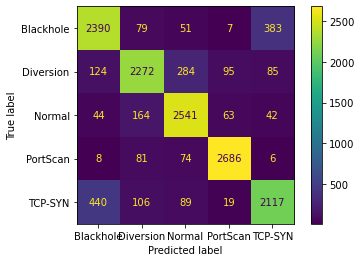

In [55]:
disp_model.plot()

In [56]:
print(metrics.classification_report(Y_test, knn_X_test_pred, digits=3))

              precision    recall  f1-score   support

           1      0.795     0.821     0.808      2910
           2      0.841     0.794     0.817      2860
           3      0.836     0.890     0.862      2854
           5      0.936     0.941     0.938      2855
           6      0.804     0.764     0.783      2771

    accuracy                          0.843     14250
   macro avg      0.842     0.842     0.842     14250
weighted avg      0.842     0.843     0.842     14250



In [57]:
### SVM

In [58]:
svm_model_test=confusion_matrix(Y_test, model_X_test_pred)

In [59]:
svm_model_test

array([[2289,   25,    0,    0,  596],
       [ 603,  684,  770,  203,  600],
       [ 233,  370, 1519,  233,  499],
       [  15,  130,  352, 2138,  220],
       [1504,  161,   12,    1, 1093]], dtype=int64)

In [60]:
disp_model = ConfusionMatrixDisplay(confusion_matrix=svm_model_test, display_labels=["Blackhole", "Diversion", "Normal", "PortScan", "TCP-SYN" ])

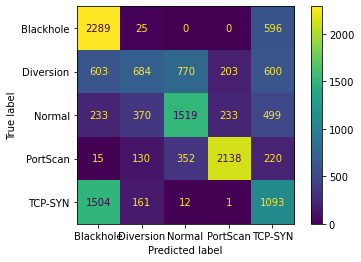

In [61]:
disp_model.plot()

In [62]:
print(metrics.classification_report(Y_test, model_X_test_pred, digits=3))

              precision    recall  f1-score   support

           1      0.493     0.787     0.606      2910
           2      0.499     0.239     0.323      2860
           3      0.573     0.532     0.552      2854
           5      0.830     0.749     0.787      2855
           6      0.363     0.394     0.378      2771

    accuracy                          0.542     14250
   macro avg      0.552     0.540     0.529     14250
weighted avg      0.553     0.542     0.530     14250



In [89]:
from datetime import datetime

In [93]:
x = datetime.now()  

In [94]:
y = datetime.now()  

In [95]:
z = y - x

In [96]:
z

datetime.timedelta(seconds=1, microseconds=149637)